# Knowledge Distillation Core Runner (Colab)

This notebook runs:
1. Teacher training on CIFAR-10 (checkpoint flow)
2. Baseline vs embedding distillation for two students
3. Multi-student comparison table/plots
4. Embedding visualizations (PCA + t-SNE)

In [1]:
REPO_URL = 'https://github.com/huz-n/knowledge_distillation.git'
REPO_DIR = '/content/knowledge_distillation'

import os
if os.path.exists(REPO_DIR):
    %cd /content/knowledge_distillation
    !git pull
else:
    %cd /content
    !git clone $REPO_URL
    %cd /content/knowledge_distillation

/content
Cloning into 'knowledge_distillation'...
remote: Enumerating objects: 33, done.
remote: Counting objects: 100% (33/33), done.
remote: Compressing objects: 100% (28/28), done.
remote: Total 33 (delta 15), reused 22 (delta 4), pack-reused 0 (from 0)
Receiving objects: 100% (33/33), 18.28 KiB | 18.28 MiB/s, done.
Resolving deltas: 100% (15/15), done.
/content/knowledge_distillation


In [2]:
!python -m pip install -q --upgrade pip
!pip install -q -r requirements.txt
!python -c "import torch; print('Torch:', torch.__version__, 'CUDA:', torch.cuda.is_available())"

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 35.6 MB/s eta 0:00:00
Torch: 2.10.0+cu128 CUDA: True


In [13]:
# Shared compact settings (increase later)
EPOCHS_TEACHER = 15
EPOCHS_STUDENT = 15
BATCH_SIZE = 64
IMAGE_SIZE = 160
MAX_TRAIN_BATCHES = 80
MAX_VAL_BATCHES = 25

In [14]:
# 1) Train teacher (ResNet-50) on CIFAR-10
!python -m src.train_teacher \
  --teacher-model resnet50 \
  --teacher-pretrained \
  --epochs $EPOCHS_TEACHER \
  --batch-size $BATCH_SIZE \
  --image-size $IMAGE_SIZE \
  --max-train-batches $MAX_TRAIN_BATCHES \
  --max-val-batches $MAX_VAL_BATCHES \
  --output-dir ./outputs/teacher_resnet50

[Epoch 1] train_loss=0.7481 train_acc=0.7814 val_loss=0.3399 val_acc=0.8912 time=16.3s
[Epoch 2] train_loss=0.3318 train_acc=0.8924 val_loss=0.2391 val_acc=0.9194 time=15.3s
[Epoch 3] train_loss=0.2796 train_acc=0.9098 val_loss=0.2548 val_acc=0.9144 time=15.8s
[Epoch 4] train_loss=0.2442 train_acc=0.9219 val_loss=0.2155 val_acc=0.9300 time=15.1s
[Epoch 5] train_loss=0.1804 train_acc=0.9365 val_loss=0.2292 val_acc=0.9237 time=14.6s
[Epoch 6] train_loss=0.1957 train_acc=0.9367 val_loss=0.2046 val_acc=0.9306 time=16.0s
[Epoch 7] train_loss=0.1567 train_acc=0.9490 val_loss=0.1854 val_acc=0.9381 time=14.8s
[Epoch 8] train_loss=0.1281 train_acc=0.9578 val_loss=0.1596 val_acc=0.9444 time=15.2s
[Epoch 9] train_loss=0.1170 train_acc=0.9605 val_loss=0.1420 val_acc=0.9563 time=14.9s
[Epoch 10] train_loss=0.1018 train_acc=0.9656 val_loss=0.1286 val_acc=0.9531 time=16.2s
[Epoch 11] train_loss=0.0804 train_acc=0.9734 val_loss=0.1132 val_acc=0.9575 time=14.7s
[Epoch 12] train_loss=0.0771 train_acc=0.

In [15]:
# 2) Student A: ResNet-18 baseline
!python -m src.train_baseline \
  --student resnet18 \
  --epochs $EPOCHS_STUDENT \
  --batch-size $BATCH_SIZE \
  --image-size $IMAGE_SIZE \
  --max-train-batches $MAX_TRAIN_BATCHES \
  --max-val-batches $MAX_VAL_BATCHES \
  --output-dir ./outputs/baseline_resnet18

[Epoch 1] train_loss=1.7526 train_acc=0.3549 val_loss=1.7299 val_acc=0.3962 time=10.0s
[Epoch 2] train_loss=1.4338 train_acc=0.4732 val_loss=1.6424 val_acc=0.4263 time=9.4s
[Epoch 3] train_loss=1.3088 train_acc=0.5246 val_loss=1.3309 val_acc=0.5138 time=8.3s
[Epoch 4] train_loss=1.2055 train_acc=0.5604 val_loss=1.3807 val_acc=0.5131 time=9.5s
[Epoch 5] train_loss=1.1410 train_acc=0.5990 val_loss=1.2128 val_acc=0.5800 time=9.4s
[Epoch 6] train_loss=1.0483 train_acc=0.6295 val_loss=1.2140 val_acc=0.5763 time=8.9s
[Epoch 7] train_loss=0.9783 train_acc=0.6443 val_loss=1.0698 val_acc=0.6150 time=8.9s
[Epoch 8] train_loss=0.9172 train_acc=0.6813 val_loss=1.0465 val_acc=0.6344 time=9.4s
[Epoch 9] train_loss=0.8544 train_acc=0.6945 val_loss=0.9461 val_acc=0.6506 time=9.4s
[Epoch 10] train_loss=0.8257 train_acc=0.7121 val_loss=0.8536 val_acc=0.6844 time=8.3s
[Epoch 11] train_loss=0.7587 train_acc=0.7301 val_loss=0.8229 val_acc=0.6994 time=9.4s
[Epoch 12] train_loss=0.6866 train_acc=0.7643 val_l

In [16]:
# 3) Student A: ResNet-18 distillation
!python -m src.train_distill \
  --student resnet18 \
  --teacher resnet50 \
  --teacher-checkpoint ./outputs/teacher_resnet50/teacher_best.pt \
  --distill-loss mse \
  --alpha 1.0 \
  --beta 1.0 \
  --epochs $EPOCHS_STUDENT \
  --batch-size $BATCH_SIZE \
  --image-size $IMAGE_SIZE \
  --max-train-batches $MAX_TRAIN_BATCHES \
  --max-val-batches $MAX_VAL_BATCHES \
  --output-dir ./outputs/distill_resnet18

[Epoch 1] train_total=2.2288 train_cls=1.7920 train_distill=0.4368 train_acc=0.3281 val_total=1.9711 val_acc=0.4350 time=12.8s
[Epoch 2] train_total=1.7777 train_cls=1.4205 train_distill=0.3572 train_acc=0.4754 val_total=1.8938 val_acc=0.4794 time=12.3s
[Epoch 3] train_total=1.6301 train_cls=1.2916 train_distill=0.3385 train_acc=0.5395 val_total=1.7964 val_acc=0.5225 time=12.6s
[Epoch 4] train_total=1.4692 train_cls=1.1533 train_distill=0.3159 train_acc=0.5861 val_total=1.5734 val_acc=0.5581 time=12.5s
[Epoch 5] train_total=1.3933 train_cls=1.0907 train_distill=0.3026 train_acc=0.6121 val_total=1.4864 val_acc=0.5825 time=12.4s
[Epoch 6] train_total=1.2875 train_cls=0.9941 train_distill=0.2934 train_acc=0.6561 val_total=1.7101 val_acc=0.5381 time=12.3s
[Epoch 7] train_total=1.2150 train_cls=0.9336 train_distill=0.2815 train_acc=0.6674 val_total=1.2941 val_acc=0.6431 time=12.2s
[Epoch 8] train_total=1.1307 train_cls=0.8584 train_distill=0.2723 train_acc=0.7070 val_total=1.3786 val_acc=0.

In [17]:
# 4) Student B: MobileNetV3-small baseline
!python -m src.train_baseline \
  --student mobilenetv3_small \
  --epochs $EPOCHS_STUDENT \
  --batch-size $BATCH_SIZE \
  --image-size $IMAGE_SIZE \
  --max-train-batches $MAX_TRAIN_BATCHES \
  --max-val-batches $MAX_VAL_BATCHES \
  --output-dir ./outputs/baseline_mobilenetv3

[Epoch 1] train_loss=2.0021 train_acc=0.2463 val_loss=2.3047 val_acc=0.0906 time=16.0s
[Epoch 2] train_loss=1.6929 train_acc=0.3609 val_loss=2.3145 val_acc=0.0906 time=10.4s
[Epoch 3] train_loss=1.5469 train_acc=0.4158 val_loss=2.3260 val_acc=0.1150 time=10.4s
[Epoch 4] train_loss=1.4821 train_acc=0.4531 val_loss=2.3457 val_acc=0.1150 time=10.4s
[Epoch 5] train_loss=1.4322 train_acc=0.4680 val_loss=2.3774 val_acc=0.1150 time=9.3s
[Epoch 6] train_loss=1.3614 train_acc=0.4992 val_loss=2.3860 val_acc=0.1469 time=10.5s
[Epoch 7] train_loss=1.3360 train_acc=0.5057 val_loss=2.1955 val_acc=0.2162 time=10.4s
[Epoch 8] train_loss=1.2910 train_acc=0.5182 val_loss=1.8530 val_acc=0.3406 time=10.4s
[Epoch 9] train_loss=1.2556 train_acc=0.5404 val_loss=1.3944 val_acc=0.4906 time=9.8s
[Epoch 10] train_loss=1.1972 train_acc=0.5678 val_loss=1.2394 val_acc=0.5594 time=9.9s
[Epoch 11] train_loss=1.1772 train_acc=0.5686 val_loss=1.1932 val_acc=0.5731 time=10.4s
[Epoch 12] train_loss=1.1557 train_acc=0.587

In [18]:
# 5) Student B: MobileNetV3-small distillation
!python -m src.train_distill \
  --student mobilenetv3_small \
  --teacher resnet50 \
  --teacher-checkpoint ./outputs/teacher_resnet50/teacher_best.pt \
  --distill-loss mse \
  --alpha 1.0 \
  --beta 1.0 \
  --epochs $EPOCHS_STUDENT \
  --batch-size $BATCH_SIZE \
  --image-size $IMAGE_SIZE \
  --max-train-batches $MAX_TRAIN_BATCHES \
  --max-val-batches $MAX_VAL_BATCHES \
  --output-dir ./outputs/distill_mobilenetv3

[Epoch 1] train_total=2.4296 train_cls=2.0012 train_distill=0.4284 train_acc=0.2479 val_total=2.7931 val_acc=0.1150 time=17.5s
[Epoch 2] train_total=2.0335 train_cls=1.6645 train_distill=0.3690 train_acc=0.3699 val_total=2.7822 val_acc=0.1150 time=11.1s
[Epoch 3] train_total=1.8969 train_cls=1.5489 train_distill=0.3481 train_acc=0.4234 val_total=2.7978 val_acc=0.1150 time=11.3s
[Epoch 4] train_total=1.7770 train_cls=1.4439 train_distill=0.3331 train_acc=0.4617 val_total=2.8529 val_acc=0.1150 time=11.5s
[Epoch 5] train_total=1.7154 train_cls=1.3879 train_distill=0.3275 train_acc=0.4842 val_total=2.9666 val_acc=0.1150 time=11.9s
[Epoch 6] train_total=1.6494 train_cls=1.3337 train_distill=0.3157 train_acc=0.5035 val_total=3.2105 val_acc=0.1175 time=11.9s
[Epoch 7] train_total=1.5948 train_cls=1.2893 train_distill=0.3055 train_acc=0.5326 val_total=2.9937 val_acc=0.0963 time=11.8s
[Epoch 8] train_total=1.5043 train_cls=1.2076 train_distill=0.2968 train_acc=0.5635 val_total=2.2250 val_acc=0.

In [19]:
# 6) Compare both students in one table/plot
!python -m src.compare_students \
  --run resnet18:./outputs/baseline_resnet18/metrics.json:./outputs/distill_resnet18/metrics.json \
  --run mobilenetv3_small:./outputs/baseline_mobilenetv3/metrics.json:./outputs/distill_mobilenetv3/metrics.json \
  --output-dir ./outputs/compare_students

[
  {
    "model": "mobilenetv3_small",
    "param_count": 932778,
    "baseline_val_acc": 0.58125,
    "baseline_test_acc": 0.5875,
    "distill_val_acc": 0.618125,
    "distill_test_acc": 0.610625
  },
  {
    "model": "resnet18",
    "param_count": 11181642,
    "baseline_val_acc": 0.73375,
    "baseline_test_acc": 0.75125,
    "distill_val_acc": 0.768125,
    "distill_test_acc": 0.77875
  }
]
Saved: outputs/compare_students/summary.json
Saved: outputs/compare_students/summary.csv
Saved: outputs/compare_students/acc_by_model.png
Saved: outputs/compare_students/acc_by_params.png


In [20]:
# 7) Embedding visualization for student A (ResNet-18)
!python -m src.visualize_embeddings \
  --student-model resnet18 \
  --teacher-model resnet50 \
  --teacher-checkpoint ./outputs/teacher_resnet50/teacher_best.pt \
  --baseline-checkpoint ./outputs/baseline_resnet18/student_best.pt \
  --distill-checkpoint ./outputs/distill_resnet18/student_best.pt \
  --max-items 1500 \
  --output-dir ./outputs/embedding_viz_resnet18

{
  "num_points": 1500,
  "teacher_dim": 2048,
  "baseline_dim_after_alignment": 2048,
  "distill_dim": 2048,
  "artifacts": [
    "pca_models.png",
    "tsne_models.png",
    "pca_by_class.png",
    "tsne_by_class.png"
  ]
}
Saved dir: outputs/embedding_viz_resnet18


[
  {
    "model": "mobilenetv3_small",
    "param_count": 932778,
    "baseline_val_acc": 0.58125,
    "baseline_test_acc": 0.5875,
    "distill_val_acc": 0.618125,
    "distill_test_acc": 0.610625
  },
  {
    "model": "resnet18",
    "param_count": 11181642,
    "baseline_val_acc": 0.73375,
    "baseline_test_acc": 0.75125,
    "distill_val_acc": 0.768125,
    "distill_test_acc": 0.77875
  }
]


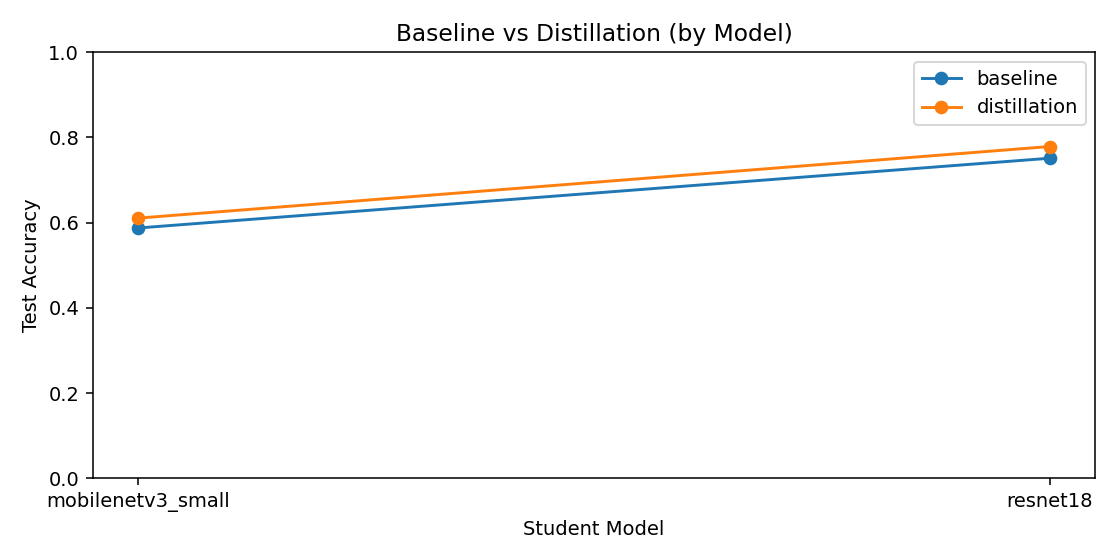

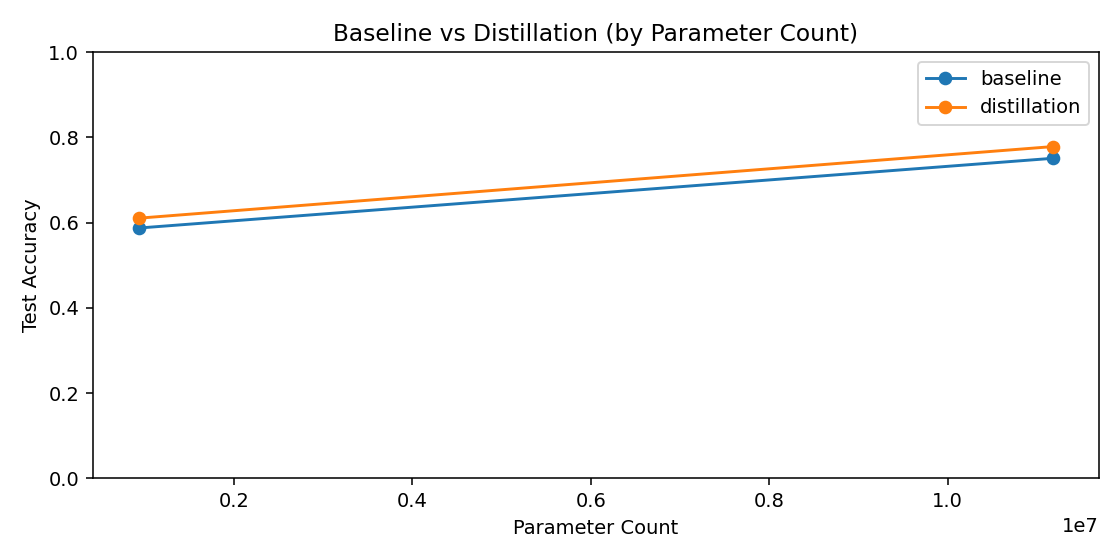

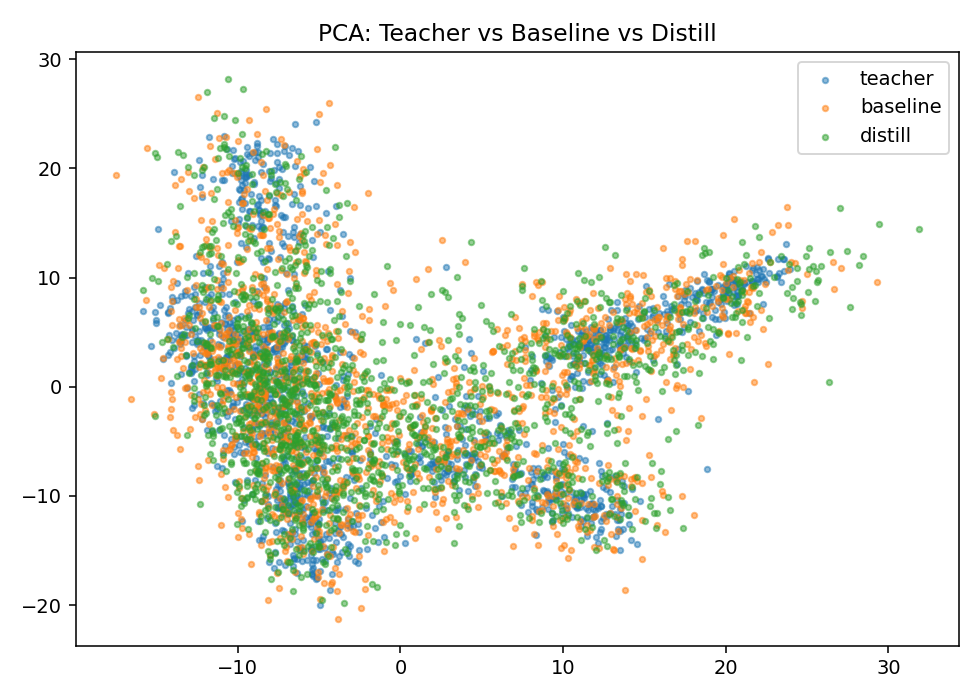

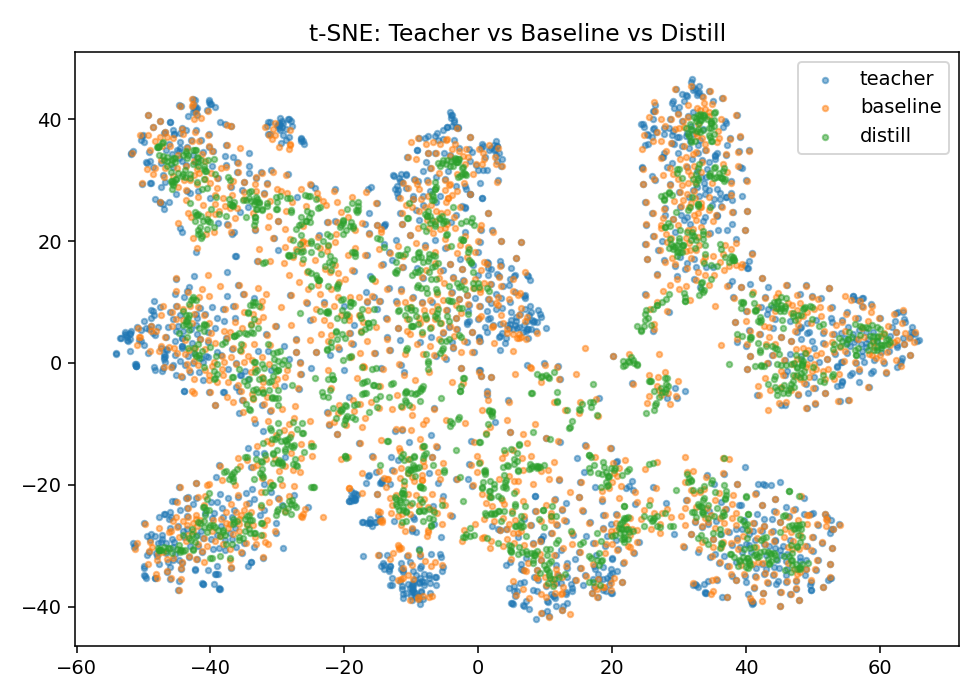

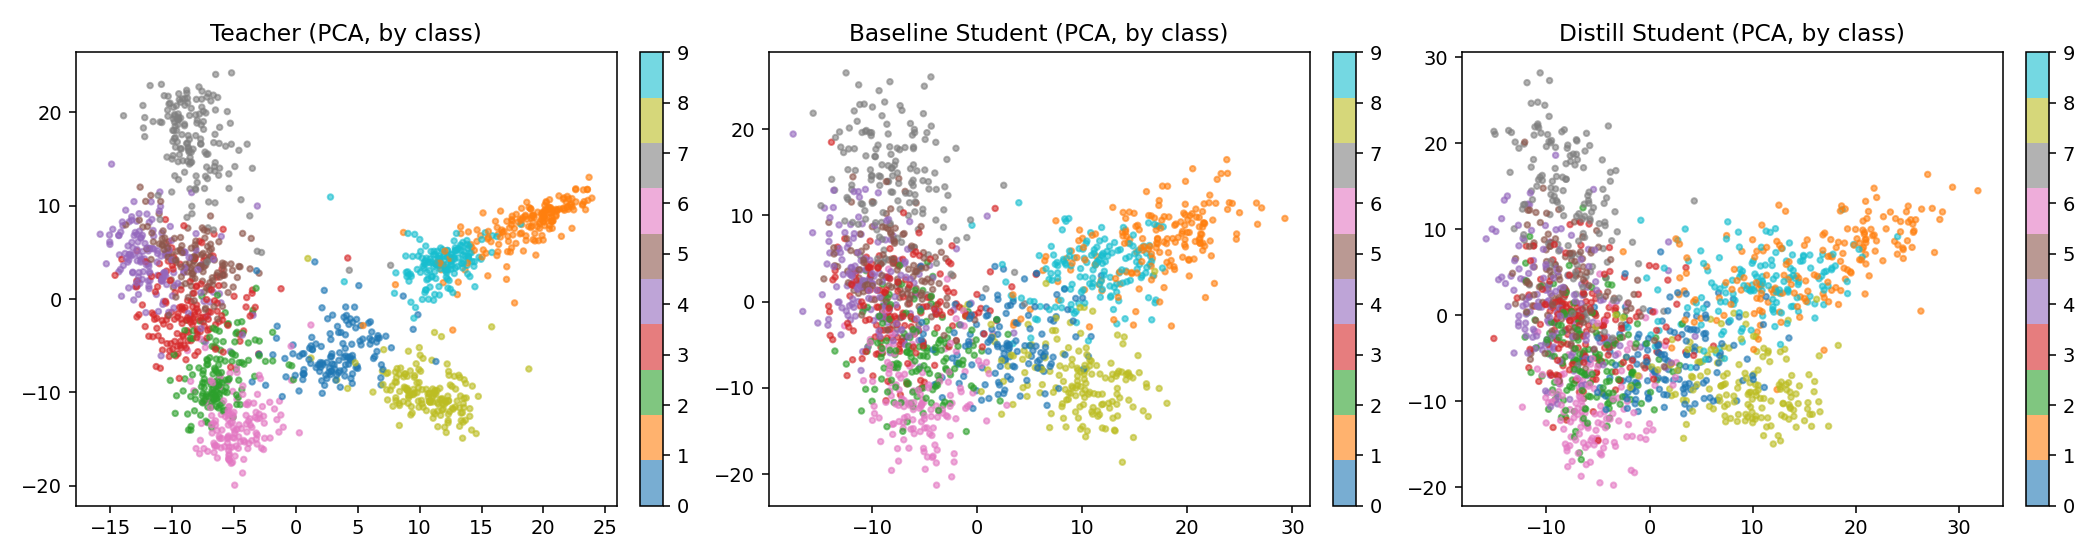

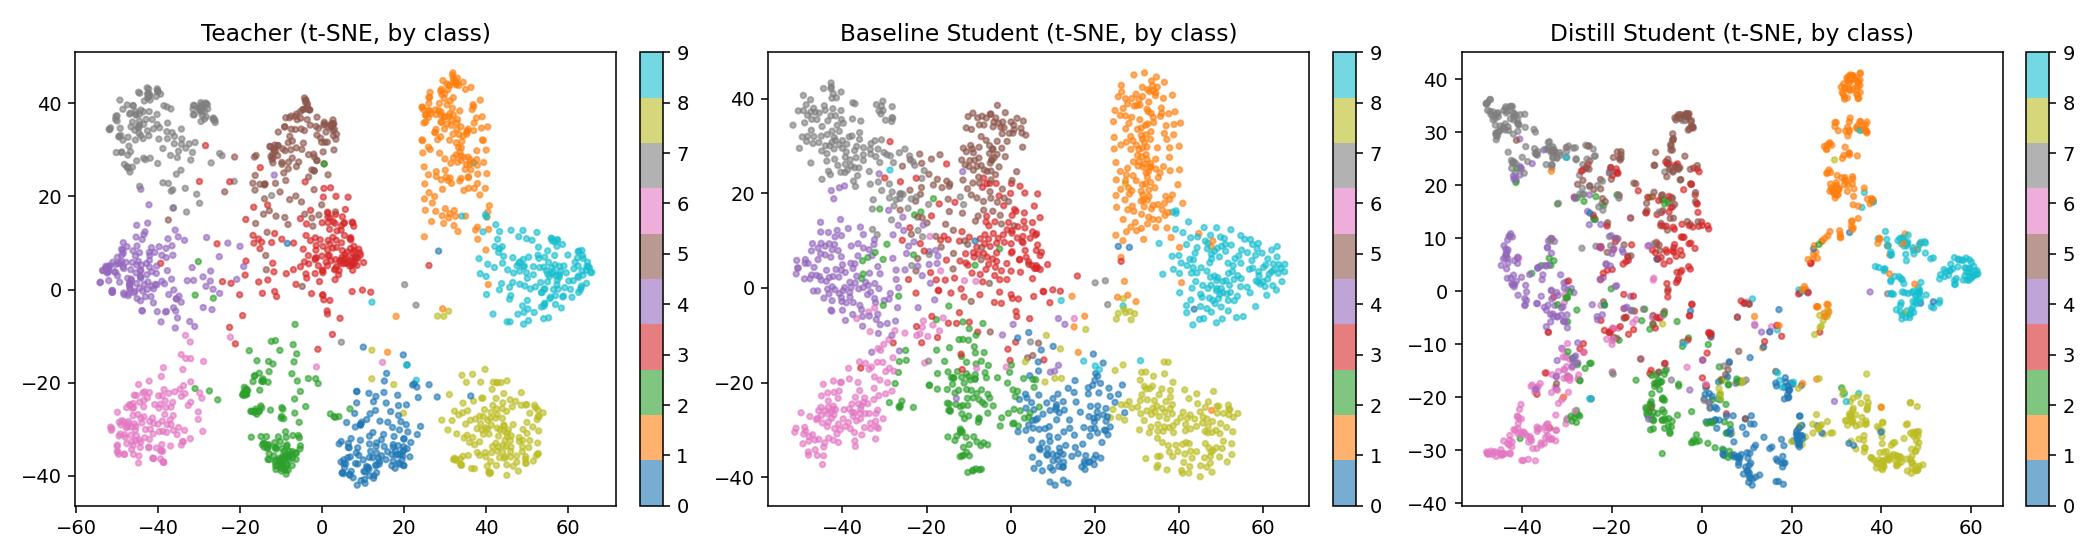

In [21]:
import json
from pathlib import Path
from IPython.display import Image, display

summary = json.loads(Path('./outputs/compare_students/summary.json').read_text())
print(json.dumps(summary, indent=2))
display(Image(filename='./outputs/compare_students/acc_by_model.png'))
display(Image(filename='./outputs/compare_students/acc_by_params.png'))
display(Image(filename='./outputs/embedding_viz_resnet18/pca_models.png'))
display(Image(filename='./outputs/embedding_viz_resnet18/tsne_models.png'))
display(Image(filename='./outputs/embedding_viz_resnet18/pca_by_class.png'))
display(Image(filename='./outputs/embedding_viz_resnet18/tsne_by_class.png'))